<a href="https://colab.research.google.com/github/MiguelFigueroa02/MCPI_Student_Repo/blob/main/courses/1-Semester/fundamentals%20of%20statistics/notes/clase_1_datos_descriptiva_visualizacion_NHANES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clase 1 · Datos, estadística descriptiva y visualización


**Fundamentos de Estadística · MCPI-UAZ**

Dr. Daniel de la Rosa Gómez

15/08/2026

Este notebook retoma los conceptos vistos en la exposición teórica y los aplica a la base **NHANES 2017–2018 preparada para el curso**.

El objetivo no es aprender comandos de memoria. En cada sección se sigue la secuencia:

$$\text{pregunta} \rightarrow \text{análisis} \rightarrow \text{resultado} \rightarrow \text{interpretación} \rightarrow \text{limitación}$$

## Objetivos

Al terminar el notebook se podrá:

- reconocer observaciones y variables;
- distinguir variables cuantitativas, nominales y ordinales;
- inspeccionar calidad de datos y valores faltantes;
- calcular e interpretar media, mediana, rango, varianza y desviación estándar;
- trabajar con cuartiles e IQR;
- identificar valores potencialmente atípicos sin eliminarlos automáticamente;
- interpretar histogramas y boxplots;
- reconocer cómo una gráfica puede inducir a una impresión equivocada;
- expresar un mismo resultado estadístico de varias maneras correctas;
- señalar explícitamente qué **no** permiten concluir los datos.

> **Regla de trabajo:** en este notebook no se harán afirmaciones sobre “todos los adultos de Estados Unidos”. El análisis es descriptivo y no ponderado, por lo que las conclusiones se referirán a **los participantes analizados en esta base**.

## 1. Preparar el entorno

Para esta clase se utilizarán principalmente:

- `pandas`: manejo de tablas y cálculo de estadísticas descriptivas;
- `numpy`: operaciones numéricas;
- `matplotlib.pyplot`: creación de gráficas;
- `Path`: construcción de rutas de archivos de forma legible.

Cuando se escribe:

```python
import pandas as pd
```

`pd` es solamente un **alias** corto para `pandas`. De manera similar, `plt` será el alias de `matplotlib.pyplot`.

Las dos instrucciones `pd.set_option(...)` no modifican los datos. Solo cambian **cómo se muestran** las tablas en pantalla.

In [1]:
# Path permite construir rutas de archivos de forma legible.
from pathlib import Path

# pandas se utiliza para trabajar con tablas de datos.
import pandas as pd

# numpy aporta herramientas para operaciones numéricas.
import numpy as np

# matplotlib.pyplot se utiliza para crear gráficas.
import matplotlib.pyplot as plt

# Estas opciones solo modifican cómo se muestran los resultados.
pd.set_option("display.max_columns", 30)      # Mostrar hasta 30 columnas.
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")  # Dos decimales.

## 2. Cargar la base

La base utilizada en esta práctica es `nhanes_curso_estudiantes.csv`.

Se encuentra en:

`Documents/Clases MCPI/Fundamentos de Estadística/NHANES_curso/datos_finales/`

`Path.home()` devuelve la carpeta personal del usuario de Windows. El operador `/` permite ir agregando carpetas hasta formar la ruta completa.

Finalmente:

```python
pd.read_csv(ruta)
```

lee el archivo CSV y crea un `DataFrame`, que es la estructura tabular principal de `pandas`.

La propiedad `df.shape` devuelve dos valores:

```text
(número de filas, número de columnas)
```

Por eso `df.shape[0]` representa las filas y `df.shape[1]` las columnas.

In [ ]:
# Construimos la ruta exacta donde se encuentra la base.
ruta = (
    Path.home()
    / "Documents"
    / "Clases MCPI"
    / "Fundamentos de Estadística"
    / "NHANES_curso"
    / "datos_finales"
    / "nhanes_curso_estudiantes.csv"
)

# read_csv() lee el archivo y crea un DataFrame de pandas.
df = pd.read_csv(ruta)

# shape[0] = número de filas; shape[1] = número de columnas.
print(f"Archivo cargado: {ruta}")
print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")

Archivo cargado: C:\Users\danie\Documents\Clases MCPI\Fundamentos de Estadística\NHANES_curso\datos_finales\nhanes_curso_estudiantes.csv
Dimensiones: 5,856 filas × 18 columnas


### Comprobación de la versión de la base

La versión para estudiantes debe contener **5,856 participantes y 18 variables**. Cada fila corresponde a un participante adulto.

También se verifican los nombres esperados para evitar continuar con otra versión del archivo sin darnos cuenta.

In [ ]:
# Lista de columnas que debe contener la versión de estudiantes.
columnas_esperadas = [
    "id", "edad_anios", "sexo", "sueno_semana_h", "sueno_finsemana_h",
    "somnolencia_diurna", "imc_kg_m2", "cintura_cm",
    "presion_sistolica_mmhg", "presion_diastolica_mmhg", "hba1c_pct",
    "colesterol_total_mg_dl", "hdl_mg_dl", "crp_mg_l",
    "actividad_moderada", "minutos_sentado_dia", "tabaquismo",
    "diabetes_reportada",
]

# Comparamos la lista esperada con las columnas realmente cargadas.
faltantes = [c for c in columnas_esperadas if c not in df.columns]
extras = [c for c in df.columns if c not in columnas_esperadas]

print("Columnas esperadas ausentes:", faltantes)
print("Columnas adicionales:", extras)

# assert detiene la ejecución si faltara alguna columna esencial.
assert not faltantes, "La base no coincide con la versión esperada para el curso."

Columnas esperadas ausentes: []
Columnas adicionales: []


## 3. Observaciones y variables

Antes de calcular cualquier estadístico conviene **mirar la estructura de la base**.

En esta base:

- una fila representa un participante;
- una columna representa una variable o un identificador;
- `id` es un identificador anónimo y no una variable cuantitativa de interés.

La función:

```python
df.head()
```

muestra por defecto las primeras cinco filas. Se utiliza para inspeccionar rápidamente nombres de columnas, tipos de valores y apariencia general de los registros.

También utilizaremos:

- `len(df)` para contar filas;
- `df.shape[1]` para contar columnas;
- `df.columns` para consultar los nombres de las variables.

In [ ]:
# head() muestra por defecto las primeras cinco filas.
df.head()

,id,edad_anios,sexo,sueno_semana_h,sueno_finsemana_h,somnolencia_diurna,imc_kg_m2,cintura_cm,presion_sistolica_mmhg,presion_diastolica_mmhg,hba1c_pct,colesterol_total_mg_dl,hdl_mg_dl,crp_mg_l,actividad_moderada,minutos_sentado_dia,tabaquismo,diabetes_reportada
0,93705,66.00,Mujer,8.00,8.00,Nunca,31.70,101.80,202.00,62.00,6.20,157.00,60.00,2.72,Sí,300.00,Exfumador,No
1,93706,18.00,Hombre,10.50,11.50,Rara vez,21.50,79.30,111.30,73.30,5.20,148.00,47.00,0.74,Sí,240.00,Nunca,No
2,93708,66.00,Mujer,8.00,8.00,A veces,23.70,88.20,141.00,77.00,6.20,209.00,88.00,1.83,Sí,120.00,Nunca,Limítrofe
3,93709,75.00,Mujer,7.00,6.50,Rara vez,38.90,113.00,118.70,66.70,6.30,176.00,65.00,6.94,No,600.00,Actual,No
4,93711,56.00,Hombre,7.00,9.00,A menudo,21.30,86.60,101.30,66.70,5.70,238.00,72.00,0.82,Sí,420.00,Nunca,No


In [ ]:
# len(df) cuenta las filas del DataFrame.
print("Número de observaciones:", len(df))

# shape[1] devuelve el número de columnas.
print("Número de variables:", df.shape[1])

# df.columns contiene los nombres de las columnas.
print("\nNombres de las variables:")
for columna in df.columns:
    print(" -", columna)

Número de observaciones: 5856
Número de variables: 18

Nombres de las variables:
 - id
 - edad_anios
 - sexo
 - sueno_semana_h
 - sueno_finsemana_h
 - somnolencia_diurna
 - imc_kg_m2
 - cintura_cm
 - presion_sistolica_mmhg
 - presion_diastolica_mmhg
 - hba1c_pct
 - colesterol_total_mg_dl
 - hdl_mg_dl
 - crp_mg_l
 - actividad_moderada
 - minutos_sentado_dia
 - tabaquismo
 - diabetes_reportada


### Primera lectura del tipo de variables

Una clasificación útil para esta clase es:

**Cuantitativas**
- `edad_anios`
- `sueno_semana_h`
- `sueno_finsemana_h`
- `imc_kg_m2`
- `cintura_cm`
- `presion_sistolica_mmhg`
- `presion_diastolica_mmhg`
- `hba1c_pct`
- `colesterol_total_mg_dl`
- `hdl_mg_dl`
- `crp_mg_l`
- `minutos_sentado_dia`

**Categóricas nominales**
- `sexo`
- `actividad_moderada`
- `tabaquismo`
- `diabetes_reportada`

**Categórica ordinal**
- `somnolencia_diurna`

Hay dos cautelas importantes:

1. `edad_anios = 80` significa **80 años o más**, no exactamente 80.
2. En las variables de sueño, `2` representa **menos de 3 horas** y `14` representa **14 horas o más**.

Que una variable se almacene como número no significa que todas sus operaciones sean interpretables de la misma manera.

## 4. Inspección inicial: tipos de almacenamiento

La propiedad:

```python
df.dtypes
```

muestra cómo `pandas` almacena cada columna.

Algunos tipos habituales son:

- `int64`: números enteros;
- `float64`: números que pueden incluir decimales y valores faltantes;
- `object`: normalmente texto o categorías almacenadas como texto.

Esto describe el **tipo informático**, no el tipo estadístico. Una variable ordinal puede estar almacenada como texto y un código numérico puede no representar una cantidad.

In [ ]:
# dtypes muestra el tipo de almacenamiento de cada columna.
df.dtypes

id                           int64
edad_anios                 float64
sexo                        object
sueno_semana_h             float64
sueno_finsemana_h          float64
somnolencia_diurna          object
imc_kg_m2                  float64
cintura_cm                 float64
presion_sistolica_mmhg     float64
presion_diastolica_mmhg    float64
hba1c_pct                  float64
colesterol_total_mg_dl     float64
hdl_mg_dl                  float64
crp_mg_l                   float64
actividad_moderada          object
minutos_sentado_dia        float64
tabaquismo                  object
diabetes_reportada          object
dtype: object

## 5. Calidad de datos: ¿cuántos valores faltan?

Antes de calcular una media o construir una gráfica conviene saber cuántas observaciones están realmente disponibles.

No existe necesariamente un único `n` para toda la base. El tamaño efectivo depende de las variables utilizadas en cada análisis.

En el código se emplean estas funciones:

- `df.notna()`: marca con `True` las celdas que contienen un dato disponible;
- `df.isna()`: marca con `True` las celdas con dato faltante;
- `.sum()`: cuenta los `True` porque Python los trata como 1;
- `.mean()`: aplicada a `True/False`, calcula la proporción de `True`;
- `.sort_values(...)`: ordena la tabla según una columna.

Así, `df.isna().mean() * 100` calcula el porcentaje de valores faltantes por variable.

In [ ]:
# notna().sum() cuenta los datos disponibles por variable.
n_disponible = df.notna().sum()

# isna().sum() cuenta los datos faltantes por variable.
n_faltante = df.isna().sum()

# La media de True/False equivale a una proporción.
porcentaje_faltante = df.isna().mean() * 100

# Construimos una tabla con los tres resultados.
calidad = pd.DataFrame({
    "n_disponible": n_disponible,
    "n_faltante": n_faltante,
    "porcentaje_faltante": porcentaje_faltante,
})

# Ordenamos de mayor a menor porcentaje de faltantes.
calidad = calidad.sort_values("porcentaje_faltante", ascending=False)

calidad

,n_disponible,n_faltante,porcentaje_faltante
crp_mg_l,5146,710,12.12
hdl_mg_dl,5176,680,11.61
colesterol_total_mg_dl,5176,680,11.61
cintura_cm,5184,672,11.48
presion_diastolica_mmhg,5247,609,10.40
presion_sistolica_mmhg,5247,609,10.40
hba1c_pct,5261,595,10.16
imc_kg_m2,5434,422,7.21
sueno_finsemana_h,5800,56,0.96
sueno_semana_h,5809,47,0.80


### Cómo interpretar esta tabla

Una forma técnica de expresarlo:

> La disponibilidad de datos varía entre variables, por lo que el tamaño muestral efectivo debe reportarse para cada análisis.

Una forma más sencilla:

> No todas las personas tienen información disponible en todas las columnas.

Otra forma:

> Aunque la base tenga 5,856 filas, una media de CRP, IMC o presión arterial puede estar calculada con menos observaciones.

### Lo que **no** debe decirse

> “Los registros incompletos están mal y deben eliminarse.”

La existencia de un valor faltante no implica que toda la observación sea inútil.

## 6. Dato faltante no significa cero

Un valor faltante y un cero representan situaciones distintas.

$$0 = \text{un valor numérico observado}$$

mientras que un valor faltante significa que no existe una medición válida disponible en esa celda.

Para mostrar la diferencia utilizaremos:

```python
fillna(0)
```

que sustituye temporalmente los valores faltantes por cero.

**Aquí se usa deliberadamente como contraejemplo.** No es una recomendación de limpieza de datos.

In [ ]:
variable = "imc_kg_m2"

# mean() ignora los NaN por defecto y usa los valores disponibles.
media_correcta = df[variable].mean()

# fillna(0) sustituye temporalmente los faltantes por 0.
# Se utiliza aquí solo para mostrar por qué esa decisión puede ser incorrecta.
media_rellenando_ceros = df[variable].fillna(0).mean()

print(f"Media usando los datos disponibles: {media_correcta:.2f}")
print(f"Media si los faltantes se sustituyeran por 0: {media_rellenando_ceros:.2f}")

Media usando los datos disponibles: 29.69
Media si los faltantes se sustituyeran por 0: 27.55


### Interpretaciones posibles

**Forma 1**

> Sustituir ausencia de información por cero introduce valores que nunca fueron observados y modifica artificialmente el promedio.

**Forma 2**

> `NaN` responde “no tenemos un valor válido aquí”; `0` responde “el valor observado fue cero”. Son afirmaciones distintas.

**Forma 3**

> El software puede ejecutar `fillna(0)` sin protestar, pero que una operación sea posible no significa que sea estadísticamente adecuada.

### Lo que no podemos concluir

La presencia de faltantes, por sí sola, no nos dice **por qué** falta cada observación ni cuál sería el método adecuado para tratarla en un análisis posterior.

## 7. Variables categóricas: frecuencias y porcentajes

Para una variable categórica, una primera descripción natural es contar cuántas observaciones pertenecen a cada categoría.

La función:

```python
value_counts()
```

cuenta los casos de cada categoría.

Con:

```python
normalize=True
```

se obtienen proporciones en lugar de conteos. Al multiplicarlas por 100 se convierten en porcentajes.

La opción:

```python
dropna=False
```

indica que, si existieran valores faltantes, también se mostraran como una categoría del conteo en lugar de ocultarlos.

In [ ]:
# Conteos absolutos por categoría.
conteos = df["tabaquismo"].value_counts(dropna=False)

# normalize=True devuelve proporciones; multiplicamos por 100 para obtener porcentajes.
porcentajes = (
    df["tabaquismo"]
    .value_counts(normalize=True, dropna=False)
    * 100
)

# Reunimos conteos y porcentajes en una sola tabla.
tabla_tabaquismo = pd.DataFrame({
    "n": conteos,
    "porcentaje": porcentajes,
})

tabla_tabaquismo

,n,porcentaje
tabaquismo,,
Nunca,3497,59.72
Exfumador,1338,22.85
Actual,1021,17.44


### Varias maneras correctas de comunicar el mismo resultado

A partir de la tabla anterior pueden construirse frases como:

**Técnica**

> La categoría con mayor frecuencia en la muestra es “Nunca”, seguida de “Exfumador” y “Actual”.

**Cotidiana**

> En esta base hay más personas que reportan no haber fumado que personas clasificadas como fumadoras actuales o exfumadoras.

**Con porcentaje**

> Aproximadamente seis de cada diez participantes están en la categoría “Nunca”.

Las tres pueden ser correctas si reflejan los valores obtenidos.

### Una formulación que debe evitarse

> “Seis de cada diez adultos estadounidenses nunca han fumado.”

En este notebook no se están aplicando los pesos ni el diseño muestral necesarios para transformar directamente la descripción de esta muestra en una estimación poblacional.

### Práctica breve

Repetir la descripción con `actividad_moderada`.

Antes de ejecutar, anticipar:

1. ¿Es una variable cuantitativa o categórica?
2. ¿Tiene sentido calcular su media directamente?
3. ¿Qué resumen será más natural: media y desviación estándar, o conteos y porcentajes?

In [ ]:
# Repetimos el mismo procedimiento con actividad_moderada.
tabla_actividad = pd.DataFrame({
    "n": df["actividad_moderada"].value_counts(dropna=False),
    "porcentaje": (
        df["actividad_moderada"]
        .value_counts(normalize=True, dropna=False)
        * 100
    ),
})

tabla_actividad

,n,porcentaje
actividad_moderada,,
No,3548,60.59
Sí,2308,39.41


## 8. Medidas de centro: media y mediana

Para una muestra con valores:

$$x_1,x_2,\ldots,x_n$$

la media se define como:

$$\bar{x}=\frac{1}{n}\sum_{i=1}^{n}x_i$$

La mediana corresponde al punto central de los valores ordenados.

Trabajaremos con `crp_mg_l`, porque su distribución permite observar claramente que media y mediana pueden contar historias diferentes.

En el código:

- `.dropna()` conserva únicamente los valores disponibles de esa variable;
- `.mean()` calcula la media;
- `.median()` calcula la mediana.

`dropna()` se aplica aquí **solo a la serie de CRP**. No se eliminan esas personas de la base completa.

In [ ]:
# Seleccionamos la variable y omitimos solo sus valores faltantes.
crp = df["crp_mg_l"].dropna()

# Medidas de centro.
media_crp = crp.mean()
mediana_crp = crp.median()

print(f"n disponible = {len(crp):,}")
print(f"Media = {media_crp:.2f} mg/L")
print(f"Mediana = {mediana_crp:.2f} mg/L")

n disponible = 5,146
Media = 4.17 mg/L
Mediana = 1.94 mg/L


In [ ]:

# Seleccionamos la variable y omitimos solo sus valores faltantes.
años = df["edad_anios"].dropna()

# Medidas de centro.
media_años = años.mean()
mediana_años = años.median()

print(f"n disponible = {len(crp):,}")
print(f"Media = {media_años:.2f} años")
print(f"Mediana = {mediana_años:.2f} años")

n disponible = 5,146
Media = 49.89 años
Mediana = 51.00 años


### Interpretación

Si la ejecución reproduce la versión preparada para el curso, la media será considerablemente mayor que la mediana.

Eso sugiere que algunos valores altos están desplazando la media hacia arriba.

### Varias maneras correctas de decirlo

**Técnica**

> La CRP presenta una diferencia marcada entre media y mediana, compatible con una distribución asimétrica hacia valores altos.

**Más accesible**

> La mayoría de los valores se concentra más abajo de lo que sugiere el promedio, porque algunos valores elevados empujan la media hacia arriba.

**Muy breve**

> La media parece poco representativa por sí sola.

### Lo que no debe decirse

> “La media está mal.”

La media está correctamente calculada. La cuestión es **qué tan representativa resulta para describir el centro de esta distribución**.

## 9. Ver la distribución: histograma de CRP

Una diferencia entre media y mediana es una pista, pero una gráfica permite observar directamente la forma de la distribución.

La función principal será:

```python
plt.hist(crp, bins=40)
```

- `crp` indica los datos que se representarán;
- `bins=40` divide el rango observado en 40 intervalos;
- `plt.figure(figsize=(8, 4.5))` establece el tamaño de la figura;
- `xlabel`, `ylabel` y `title` agregan etiquetas;
- `plt.show()` muestra la gráfica.

El número de `bins` es una decisión de visualización: pocos intervalos pueden ocultar estructura y demasiados pueden producir demasiado ruido.

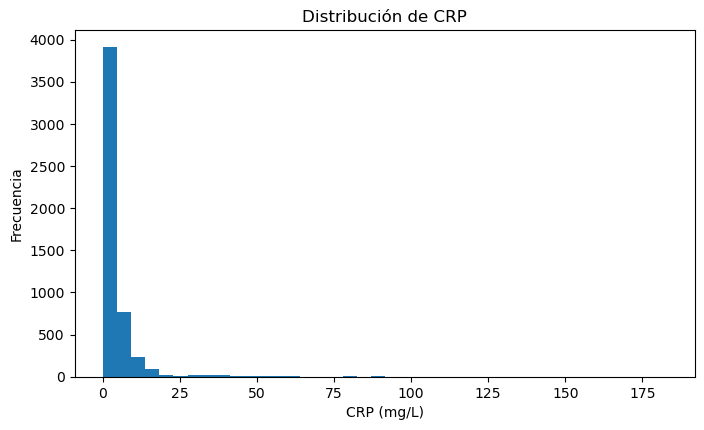

In [ ]:
# Creamos una figura de 8 × 4.5 pulgadas.
plt.figure(figsize=(8, 4.5))

# hist() construye el histograma; bins=40 usa 40 intervalos.
plt.hist(crp, bins=40)

# Agregamos etiquetas para que la gráfica sea interpretable por sí sola.
plt.xlabel("CRP (mg/L)")
plt.ylabel("Frecuencia")
plt.title("Distribución de CRP")

# show() muestra la figura.
plt.show()

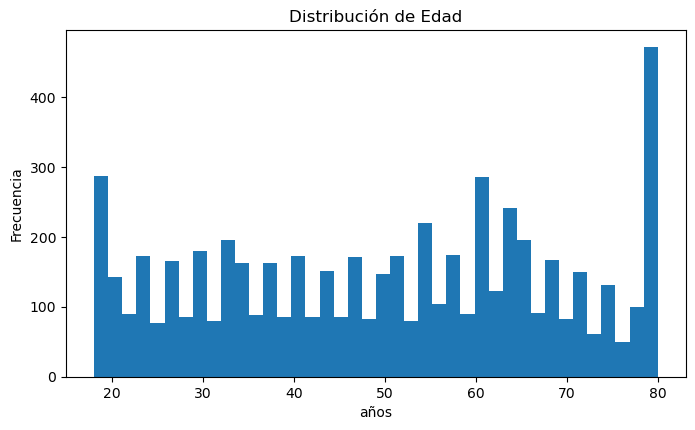

In [ ]:
# Creamos una figura de 8 × 4.5 pulgadas.
plt.figure(figsize=(8, 4.5))

# hist() construye el histograma; bins=40 usa 40 intervalos.
plt.hist(años, bins=40)

# Agregamos etiquetas para que la gráfica sea interpretable por sí sola.
plt.xlabel("años")
plt.ylabel("Frecuencia")
plt.title("Distribución de Edad")

# show() muestra la figura.
plt.show()

### Qué buscar en el histograma

- ¿Dónde se concentra la mayor parte de los valores?
- ¿La distribución parece simétrica?
- ¿Hay una cola larga?
- ¿Existen valores muy alejados del conjunto principal?

### Una interpretación posible

> La distribución concentra muchas observaciones en valores bajos y presenta una cola larga hacia la derecha.

### Otra manera de expresarlo

> Hay pocos valores muy altos en comparación con la mayoría de las observaciones.

### Importante

Una distribución asimétrica **no está defectuosa** por ser asimétrica. La forma puede ser una característica real de la variable.

## 10. Comparación: una variable más concentrada

Ahora observaremos `sueno_semana_h` para comparar una distribución distinta.

Se utilizarán exactamente las mismas ideas:

1. seleccionar los valores disponibles con `.dropna()`;
2. calcular media y mediana;
3. construir un histograma;
4. comparar su forma con la observada en CRP.

La comparación es importante: **no todas las variables deben describirse mediante una receta idéntica**.

Sueño: media = 7.64 h
Sueño: mediana = 8.00 h


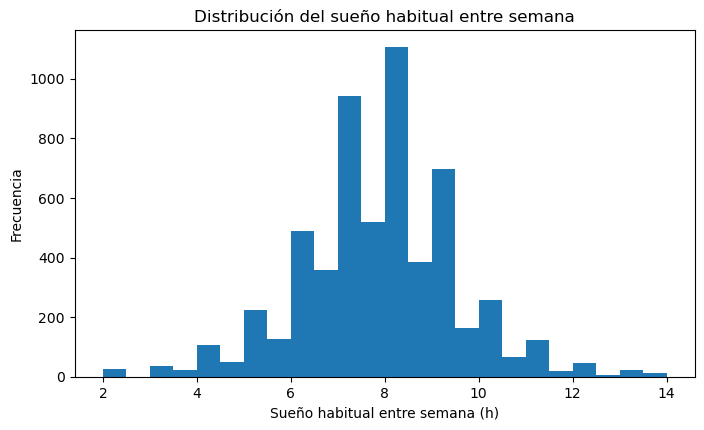

In [ ]:
# Seleccionamos los valores disponibles de sueño entre semana.
sueno = df["sueno_semana_h"].dropna()

# Comparamos media y mediana.
print(f"Sueño: media = {sueno.mean():.2f} h")
print(f"Sueño: mediana = {sueno.median():.2f} h")

# Construimos el histograma.
plt.figure(figsize=(8, 4.5))
plt.hist(sueno, bins=24)
plt.xlabel("Sueño habitual entre semana (h)")
plt.ylabel("Frecuencia")
plt.title("Distribución del sueño habitual entre semana")
plt.show()

### Cautela de codificación

Aquí los extremos requieren una lectura especial:

- `2` significa **menos de 3 horas**;
- `14` significa **14 horas o más**.

Por tanto, una barra en 14 no significa que todas esas personas duerman exactamente 14 horas.

### Comparación verbal

**CRP**

> Fuerte concentración en valores bajos y cola derecha extensa.

**Sueño**

> Mucha mayor concentración alrededor de un intervalo central y un rango limitado por la codificación utilizada.

Esta comparación muestra por qué no conviene describir todas las variables con una receta idéntica.

## 11. Dispersión: rango, varianza y desviación estándar

El centro no describe por sí solo una distribución.

El rango es:

$$R=x_{\max}-x_{\min}$$

La varianza muestral es:

$$s^2=\frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})^2$$

La desviación estándar es:

$$s=\sqrt{s^2}$$

Trabajaremos con `imc_kg_m2`.

En `pandas`:

- `.min()` obtiene el mínimo;
- `.max()` obtiene el máximo;
- `.var()` calcula la varianza muestral;
- `.std()` calcula la desviación estándar muestral.

Finalmente, `pd.Series(resumen_imc)` convierte el diccionario de resultados en una tabla vertical más cómoda de leer.

In [ ]:
# Trabajamos únicamente con valores disponibles de IMC.
imc = df["imc_kg_m2"].dropna()

# Creamos un diccionario con varias medidas descriptivas.
resumen_imc = {
    "n": len(imc),
    "media": imc.mean(),
    "mediana": imc.median(),
    "mínimo": imc.min(),
    "máximo": imc.max(),
    "rango": imc.max() - imc.min(),
    "varianza": imc.var(),
    "desviación_estándar": imc.std(),
}

# Convertimos el diccionario en una Serie para visualizarlo como tabla vertical.
pd.Series(resumen_imc)

n                     5,434.00
media                    29.69
mediana                  28.50
mínimo                   14.20
máximo                   86.20
rango                    72.00
varianza                 55.36
desviación_estándar       7.44
dtype: float64

### Formas de interpretar la desviación estándar

**Forma técnica**

> La desviación estándar cuantifica la dispersión de las observaciones alrededor de la media y se expresa en las mismas unidades que el IMC.

**Forma intuitiva**

> Un valor mayor de desviación estándar indica una distribución más extendida alrededor de su centro.

**Lo que todavía no debemos afirmar**

> “El 68 % de las personas está a una desviación estándar de la media.”

Esa regla está relacionada con distribuciones aproximadamente normales y se estudiará posteriormente. No debe aplicarse automáticamente a cualquier variable.

## 12. Cuartiles e IQR

Los cuartiles describen posiciones dentro de la distribución:

$$Q_1=P_{25}$$

$$Q_2=P_{50}=\text{mediana}$$

$$Q_3=P_{75}$$

El rango intercuartílico es:

$$IQR=Q_3-Q_1$$

En `pandas`, la función:

```python
quantile(0.25)
```

calcula el percentil 25. De manera análoga, `quantile(0.50)` calcula la mediana y `quantile(0.75)` el tercer cuartil.

In [ ]:
# quantile() calcula cuantiles de la distribución.
q1 = imc.quantile(0.25)   # Percentil 25.
q2 = imc.quantile(0.50)   # Percentil 50 = mediana.
q3 = imc.quantile(0.75)   # Percentil 75.

# El IQR es la diferencia entre Q3 y Q1.
iqr = q3 - q1

print(f"Q1 = {q1:.2f}")
print(f"Q2 / mediana = {q2:.2f}")
print(f"Q3 = {q3:.2f}")
print(f"IQR = {iqr:.2f}")

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
Q1 = 24.60
Q2 / mediana = 28.50
Q3 = 33.50
IQR = 8.90


### Varias maneras correctas de interpretar el IQR

**Forma 1**

> La mitad central de los valores de IMC se encuentra entre \(Q_1\) y \(Q_3\).

**Forma 2**

> Aproximadamente 50 % de los valores se concentra dentro de un intervalo de amplitud igual al IQR.

**Forma 3**

> El IQR describe variabilidad central sin depender directamente del mínimo y del máximo.

Ninguna de estas frases afirma que todos los datos estén dentro del IQR.

## 13. Regla de 1.5 × IQR y valores potencialmente atípicos

Una regla exploratoria habitual considera potencialmente atípicos los valores menores que:

$$L_{\text{inferior}}=Q_1-1.5(IQR)$$

o mayores que:

$$L_{\text{superior}}=Q_3+1.5(IQR)$$

En el código se construyen dos condiciones:

```python
imc < limite_inferior
```

y:

```python
imc > limite_superior
```

El operador `|` significa **“o”** cuando se combinan condiciones de `pandas`.

Por tanto, se seleccionan observaciones que cumplen una condición **o** la otra.

In [ ]:
# Límites de la regla 1.5 × IQR.
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

# | significa "o" al combinar condiciones de pandas.
condicion_atipico = (imc < limite_inferior) | (imc > limite_superior)

# Conservamos solamente los valores que cumplen esa condición.
atipicos_imc = imc[condicion_atipico]

print(f"Límite inferior: {limite_inferior:.2f}")
print(f"Límite superior: {limite_superior:.2f}")
print(f"Valores señalados: {len(atipicos_imc):,}")
print(f"Porcentaje: {100 * len(atipicos_imc) / len(imc):.2f}%")

Límite inferior: 11.25
Límite superior: 46.85
Valores señalados: 156
Porcentaje: 2.87%


In [ ]:
# Ordenamos de mayor a menor y mostramos solo los primeros 10.
atipicos_imc.sort_values(ascending=False).head(10)

2730   86.20
5741   84.40
278    74.80
4077   72.60
5605   68.20
2926   67.70
140    66.20
2239   65.80
5145   65.30
2911   64.70
Name: imc_kg_m2, dtype: float64

### ¿Qué significa encontrar esos valores?

**Interpretación correcta**

> Según la regla de \(1.5\times IQR\), esas observaciones son inusuales respecto de la parte central de la distribución.

**También puede decirse**

> Son observaciones que merecen inspección adicional.

### Interpretaciones incorrectas

> “Son errores.”

> “Hay que borrarlas.”

> “Están fuera del rango permitido.”

La regla del IQR no permite sostener ninguna de esas afirmaciones por sí sola.

### Pregunta clave

**¿Qué información adicional necesitaríamos antes de decidir eliminar una observación?**

Por ejemplo: conocer el proceso de medición, posibles errores de captura, límites físicamente plausibles y el propósito concreto del análisis.

## 14. Boxplot

El boxplot resume una distribución mediante:

- `Q1`;
- mediana;
- `Q3`;
- IQR;
- valores potencialmente atípicos.

La instrucción:

```python
plt.boxplot(imc, vert=False)
```

crea el boxplot del IMC.

La opción `vert=False` hace que aparezca horizontalmente, lo que facilita leer la escala de la variable.

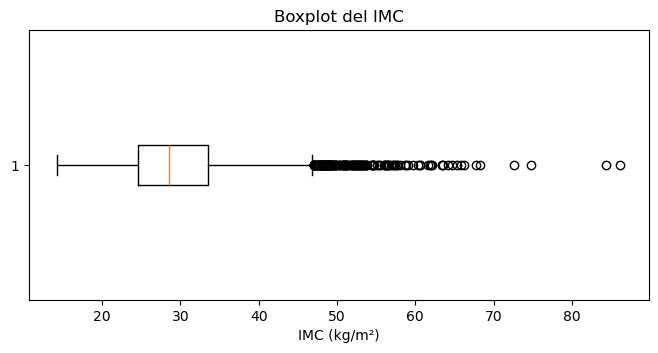

In [ ]:
plt.figure(figsize=(8, 3.5))

# vert=False hace horizontal el boxplot.
plt.boxplot(imc, vert=False)

plt.xlabel("IMC (kg/m²)")
plt.title("Boxplot del IMC")
plt.show()

### Cómo leerlo

La caja corresponde aproximadamente al 50 % central de los datos.

La línea dentro de la caja representa la mediana.

Los puntos alejados de los bigotes se señalan mediante la regla utilizada por el boxplot.

### Dos formas correctas de verbalizarlo

> La mayoría central de los valores se concentra dentro de la caja, mientras que aparecen observaciones más alejadas hacia valores altos.

o:

> La distribución presenta una cola de observaciones elevadas que el boxplot identifica como potencialmente atípicas.

### Lo que no muestra bien el boxplot

El boxplot resume mucho la distribución. No permite ver con claridad si existen varios picos, huecos o detalles finos de la forma. Por eso se complementa con el histograma.

## 15. Histograma y boxplot cuentan historias complementarias

Comparemos ambas representaciones del IMC por separado.

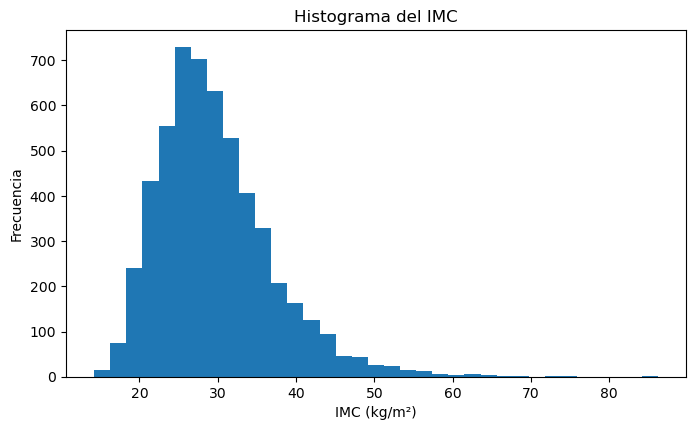

In [ ]:
plt.figure(figsize=(8, 4.5))

# Usamos 35 intervalos para visualizar la forma del IMC.
plt.hist(imc, bins=35)

plt.xlabel("IMC (kg/m²)")
plt.ylabel("Frecuencia")
plt.title("Histograma del IMC")
plt.show()

### Lectura conjunta

El **histograma** ayuda especialmente a responder:

> ¿Qué forma tiene la distribución?

El **boxplot** ayuda especialmente a responder:

> ¿Dónde están la mediana, la mitad central y los valores relativamente alejados?

Ninguna de las dos visualizaciones contiene toda la información. Elegir una gráfica también es una decisión estadística.

## 16. Un solo número puede ocultar una distribución

`pandas` ofrece una función muy útil para una primera inspección:

```python
describe()
```

Para variables cuantitativas devuelve automáticamente:

- `count`: número de datos disponibles;
- `mean`: media;
- `std`: desviación estándar;
- `min`: mínimo;
- `25%`: `Q1`;
- `50%`: mediana;
- `75%`: `Q3`;
- `max`: máximo.

La opción `.T` transpone la tabla para colocar una variable por fila y facilitar la lectura.

`describe()` es un punto de partida, no una interpretación automática.

In [ ]:
# Elegimos un subconjunto de variables cuantitativas.
variables_resumen = [
    "sueno_semana_h",
    "imc_kg_m2",
    "presion_sistolica_mmhg",
    "hba1c_pct",
    "colesterol_total_mg_dl",
    "hdl_mg_dl",
    "crp_mg_l",
    "minutos_sentado_dia",
]

# describe() calcula varias estadísticas de una sola vez.
# .T transpone la tabla para colocar una variable por fila.
df[variables_resumen].describe().T

,count,mean,std,min,25%,50%,75%,max
sueno_semana_h,"5,809.00",7.64,1.68,2.00,7.00,8.00,8.50,14.00
imc_kg_m2,"5,434.00",29.69,7.44,14.20,24.60,28.50,33.50,86.20
presion_sistolica_mmhg,"5,247.00",126.36,20.13,72.70,112.00,123.30,136.70,238.00
hba1c_pct,"5,261.00",5.84,1.09,3.80,5.30,5.60,6.00,16.20
colesterol_total_mg_dl,"5,176.00",186.88,41.24,76.00,158.00,183.00,212.00,446.00
hdl_mg_dl,"5,176.00",53.19,15.55,10.00,42.00,51.00,61.00,189.00
crp_mg_l,"5,146.00",4.17,8.20,0.11,0.88,1.94,4.48,182.82
minutos_sentado_dia,"5,811.00",331.68,199.15,0.00,180.00,300.00,480.00,"1,320.00"


### Preguntas para leer `describe()` y no solo mirarlo

Para cada variable:

1. ¿Cuántas observaciones se utilizaron?
2. ¿Qué tan distintas son media y mediana?
3. ¿Qué tan separados están \(Q_1\) y \(Q_3\)?
4. ¿El máximo está muy alejado de \(Q_3\)?
5. ¿Qué variable parece más asimétrica?
6. ¿Qué variable necesitaría una gráfica antes de intentar resumirla en una frase?

### Regla práctica

`describe()` produce estadísticas automáticamente. **La interpretación no es automática.**

## 17. Gráficas y escalas: cómo puede cambiar la impresión visual

Vamos a construir dos gráficas con **exactamente los mismos datos** y modificar únicamente la escala vertical.

Primero calculamos los porcentajes de `sexo`.

El código encadena tres operaciones:

```python
value_counts(normalize=True)
```

calcula proporciones;

```python
.mul(100)
```

multiplica cada proporción por 100;

```python
.sort_index()
```

ordena las categorías por su etiqueta.

In [ ]:
# value_counts(normalize=True) produce proporciones.
porcentaje_sexo = (
    df["sexo"]
    .value_counts(normalize=True)
    .mul(100)       # Convertimos proporciones a porcentajes.
    .sort_index()   # Ordenamos las categorías por su etiqueta.
)

porcentaje_sexo

sexo
Hombre   48.50
Mujer    51.50
Name: proportion, dtype: float64

### Gráfica A: escala desde cero

`plt.bar(...)` construye una gráfica de barras.

La instrucción:

```python
plt.ylim(0, 100)
```

fija explícitamente el eje vertical entre 0 y 100.

En una gráfica de barras, partir desde cero hace que la longitud de las barras represente directamente la magnitud relativa de los porcentajes.

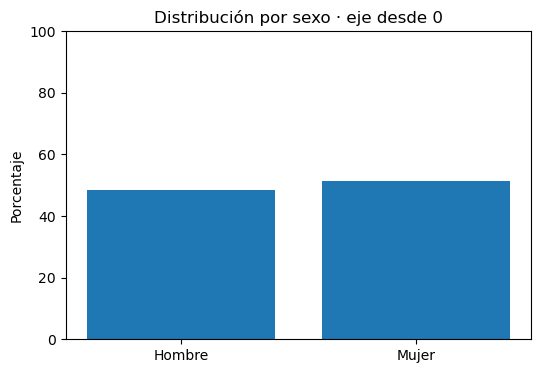

In [ ]:
plt.figure(figsize=(6, 4))

# bar() crea una gráfica de barras.
plt.bar(porcentaje_sexo.index, porcentaje_sexo.values)

# El eje vertical se fija explícitamente de 0 a 100.
plt.ylim(0, 100)

plt.ylabel("Porcentaje")
plt.title("Distribución por sexo · eje desde 0")
plt.show()

### Gráfica B: eje truncado

Ahora se utilizan **los mismos porcentajes**, pero se modifica el intervalo visible del eje vertical.

`porcentaje_sexo.min()` y `porcentaje_sexo.max()` obtienen los porcentajes menor y mayor. A partir de ellos se construye una ventana estrecha alrededor de los valores observados.

El dato no cambia; cambia solamente la presentación.

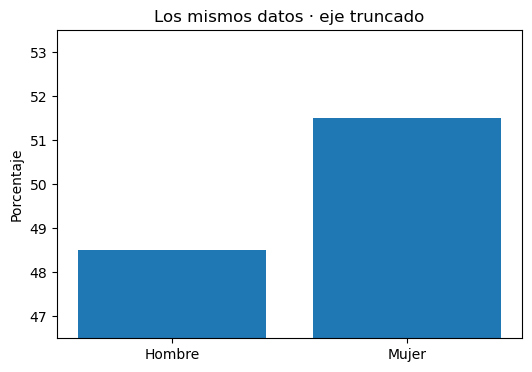

In [ ]:
# Creamos una ventana estrecha alrededor de los porcentajes observados.
ymin = max(0, porcentaje_sexo.min() - 2)
ymax = porcentaje_sexo.max() + 2

plt.figure(figsize=(6, 4))
plt.bar(porcentaje_sexo.index, porcentaje_sexo.values)

# Los datos son los mismos; únicamente cambia el rango visible del eje.
plt.ylim(ymin, ymax)

plt.ylabel("Porcentaje")
plt.title("Los mismos datos · eje truncado")
plt.show()

### Pregunta crítica

¿Cambió la diferencia numérica entre las categorías?

**No.**

¿Puede cambiar la impresión visual?

**Sí.**

### Varias maneras de decirlo

> La escala del eje no cambia los datos, pero sí puede modificar la percepción de la magnitud de la diferencia.

> Una representación gráficamente dramática no implica una diferencia numéricamente grande.

> Los datos pueden ser correctos y la presentación, aun así, inducir a una interpretación exagerada.

### Matiz importante

Un eje que no comienza en cero **no siempre es incorrecto**. Puede ser útil para examinar pequeñas variaciones. El problema aparece cuando la elección de escala oculta el contexto o exagera visualmente una diferencia.

## 18. Población, muestra y lenguaje de las conclusiones

NHANES tiene un diseño muestral complejo. La versión de estudiantes se utiliza aquí **sin ponderación** para aprender procedimientos básicos.

Por eso debemos distinguir entre estas frases.

### Apropiada

> En los participantes de esta base, aproximadamente X % pertenece a la categoría...

### También apropiada

> Dentro de la muestra analizada observamos...

### No justificada en este análisis

> X % de los adultos de Estados Unidos...

La última frase es una afirmación poblacional y requeriría incorporar correctamente el diseño muestral.

## 19. Un detalle de medición puede cambiar la interpretación

Antes de interpretar un número es necesario conocer cómo fue codificada la variable.

En el código se utiliza:

- `value_counts()` para contar cada valor;
- `sort_index()` para ordenarlos por su valor numérico;
- `head()` para mostrar los menores;
- `tail()` para mostrar los mayores.

Esto permitirá revisar específicamente los extremos de edad y sueño.

In [ ]:
print("Valores más altos de edad:")

# value_counts() cuenta cada valor, sort_index() los ordena,
# y tail() conserva los valores más altos.
print(df["edad_anios"].value_counts().sort_index().tail())

print("\nValores extremos de sueño entre semana:")

# head() muestra los valores más bajos.
print(df["sueno_semana_h"].value_counts().sort_index().head())

# tail() muestra los valores más altos.
print(df["sueno_semana_h"].value_counts().sort_index().tail())

Valores más altos de edad:
edad_anios
76.00     49
77.00     53
78.00     47
79.00     45
80.00    427
Name: count, dtype: int64

Valores extremos de sueño entre semana:
sueno_semana_h
2.00     27
3.00     36
3.50     23
4.00    106
4.50     49
Name: count, dtype: int64
sueno_semana_h
12.00    45
12.50     5
13.00    21
13.50     1
14.00    13
Name: count, dtype: int64


### Interpretación obligatoria

- `edad_anios = 80` significa **80 años o más**.
- `sueno_semana_h = 2` significa **menos de 3 horas**.
- `sueno_semana_h = 14` significa **14 horas o más**.

Por tanto, sería incorrecto decir:

> “Todas las personas registradas con 80 tienen exactamente 80 años.”

o:

> “Todas las personas con valor 14 duermen exactamente 14 horas.”

Los números necesitan su **definición de medición** para ser interpretados correctamente.

## 20. Mini ejercicio: elegir una descripción

Analizaremos `minutos_sentado_dia` integrando varias medidas.

Se calcularán:

- `n` disponible;
- media;
- mediana;
- `Q1` y `Q3`;
- mínimo y máximo.

Después se observará un histograma.

La meta no es producir todos los números posibles, sino decidir **qué características de la distribución son relevantes para describirla**.

In [ ]:
# Seleccionamos los valores disponibles de minutos sentado por día.
sentado = df["minutos_sentado_dia"].dropna()

# Reunimos medidas de centro, posición y extremos.
resumen_sentado = pd.Series({
    "n": len(sentado),
    "media": sentado.mean(),
    "mediana": sentado.median(),
    "Q1": sentado.quantile(0.25),
    "Q3": sentado.quantile(0.75),
    "mínimo": sentado.min(),
    "máximo": sentado.max(),
})

resumen_sentado

In [ ]:
plt.figure(figsize=(8, 4.5))

# El histograma ayuda a valorar concentración, asimetría y cola.
plt.hist(sentado, bins=35)

plt.xlabel("Minutos sentado por día")
plt.ylabel("Frecuencia")
plt.title("Distribución del tiempo sentado")
plt.show()

### Posibles interpretaciones

**Técnica**

> La distribución del tiempo sentado presenta valores elevados en la cola derecha y la media es mayor que la mediana.

**Cotidiana**

> Algunas personas reportan tiempos muy altos, por lo que el promedio queda por encima del punto central de la distribución.

**Con cautela sobre la medición**

> El tiempo sentado es autorreportado; un valor elevado puede ser inusual, pero no debe descartarse automáticamente por parecer poco habitual.

### Lo que no permite concluir

Estos datos descriptivos no establecen por sí solos:

- que pasar más tiempo sentado cause alguna enfermedad;
- que un valor extremo sea falso;
- que la distribución observada describa exactamente a toda la población estadounidense.

## 21. Ejercicio capcioso

Se obtiene el promedio de una variable y se redacta:

> “El valor promedio es 4.17, por lo que una persona típica tiene aproximadamente 4.17.”

### Preguntas

1. ¿La media podría estar correctamente calculada?
2. ¿La interpretación necesariamente es correcta?
3. ¿Qué otras dos cosas deberían revisarse antes de utilizar la palabra “típica”?

**Idea central:** una media correcta no garantiza una interpretación correcta. Conviene revisar al menos la **mediana** y la **forma de la distribución**.

## 22. Actividad integradora guiada

Elegir **una** de estas variables:

- `presion_sistolica_mmhg`
- `hba1c_pct`
- `colesterol_total_mg_dl`
- `hdl_mg_dl`

Construir una descripción que incluya:

1. número de valores disponibles;
2. porcentaje de faltantes;
3. media;
4. mediana;
5. desviación estándar;
6. `Q1`, `Q3` e IQR;
7. histograma;
8. boxplot;
9. una interpretación técnica;
10. una explicación en lenguaje cotidiano;
11. una limitación;
12. una afirmación que **no** pueda sostenerse con estos datos.

La siguiente celda funciona como plantilla. Para repetir el análisis con otra variable basta con cambiar el contenido de:

```python
variable = "presion_sistolica_mmhg"
```

In [ ]:
# Cambiar únicamente este nombre para repetir el análisis con otra variable.
variable = "presion_sistolica_mmhg"

# Seleccionamos valores disponibles.
x = df[variable].dropna()

# Cuartiles e IQR.
q1 = x.quantile(0.25)
q3 = x.quantile(0.75)
iqr = q3 - q1

# Resumen numérico.
print(f"Variable: {variable}")
print(f"n disponible: {len(x):,}")
print(
    f"faltantes: {df[variable].isna().sum():,} "
    f"({100 * df[variable].isna().mean():.2f}%)"
)
print(f"media: {x.mean():.2f}")
print(f"mediana: {x.median():.2f}")
print(f"desviación estándar: {x.std():.2f}")
print(f"Q1: {q1:.2f}")
print(f"Q3: {q3:.2f}")
print(f"IQR: {iqr:.2f}")

# Histograma: muestra la forma de la distribución.
plt.figure(figsize=(8, 4.5))
plt.hist(x, bins=35)
plt.xlabel(variable)
plt.ylabel("Frecuencia")
plt.title(f"Histograma · {variable}")
plt.show()

# Boxplot: resume posición, dispersión central y valores alejados.
plt.figure(figsize=(8, 3.5))
plt.boxplot(x, vert=False)
plt.xlabel(variable)
plt.title(f"Boxplot · {variable}")
plt.show()

### Plantilla de verbalización

Completar oralmente o por escrito:

**Resultado**

> En la muestra analizada, la variable ______ tiene una media de ______ y una mediana de ______, calculadas con \(n=\) ______ observaciones.

**Interpretación**

> La distribución parece ______ porque ______.

**Otra manera de decirlo**

> En términos más sencillos, ______.

**Limitación**

> Este resumen debe interpretarse considerando que ______.

**Lo que NO puedo concluir**

> Estos datos no demuestran que ______.

La capacidad de expresar un mismo resultado de varias maneras ayuda a comprobar que el resultado fue realmente comprendido y no solamente calculado.

## 23. Cierre: qué debe quedar claro

Después de trabajar con la base, deberían quedar claras estas ideas:

- Cada fila representa una observación, pero no toda columna numérica representa una cantidad interpretable.
- El número total de filas no siempre coincide con el \(n\) efectivo de un análisis.
- `NaN` y cero no significan lo mismo.
- La media y la mediana describen el centro de maneras diferentes.
- Una media puede ser correcta y, aun así, poco representativa de una distribución asimétrica.
- Centro sin dispersión es una descripción incompleta.
- El IQR resume la mitad central de los datos.
- La regla de \(1.5\times IQR\) identifica observaciones inusuales; no diagnostica errores.
- Histogramas y boxplots aportan información complementaria.
- Las decisiones gráficas pueden modificar la percepción de una diferencia.
- La codificación y el procedimiento de medición forman parte del significado de los datos.
- En un análisis descriptivo no ponderado de esta base, las conclusiones deben limitarse a los participantes analizados.

## Regla final

Ante cualquier salida estadística, responder siempre:

1. **¿Qué obtuve?**
2. **¿Qué significa?**
3. **¿Cómo podría explicarlo de otra manera?**
4. **¿Qué limitación tiene?**
5. **¿Qué NO puedo concluir?**